Data sources: [US Mortality DataBase for the USA](https://usa.mortality.org/national.php?national=USA), [for California](https://usa.mortality.org/state.php?state=CA), [for New York](https://usa.mortality.org/state.php?state=NY) / [U.S State Life Tables CSV + TXT 1941-2022](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/19WYUX)<br>
Outputs placed to wiki:<br>
[List of U.S. states and territories by life expectancy](https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_life_expectancy#Data_of_the_United_States_Mortality_DataBase) <i>([alternative](https://en.wikipedia.org/wiki/User:Lady3mlnm/List_of_U.S._states_and_territories_by_life_expectancy_(alternative)#Data_of_the_United_States_Mortality_DataBase))</i> / [Продолжительность жизни в штатах США](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_штатах_США#Данные_United_States_Mortality_DataBase)<br>
[Demographics of New York (state)](https://en.wikipedia.org/wiki/Demographics_of_New_York_(state)#Percentage_surviving), [Demographics of California](https://en.wikipedia.org/wiki/Demographics_of_California#Percentage_surviving), [Hawaii](https://en.wikipedia.org/wiki/Hawaii#Percentage_surviving)<br>
<br>
[chart from the National Vital Statisctics Reports](https://commons.wikimedia.org/wiki/File:Percentage_Surviving_to_Certain_Ages_in_the_U.S..png) at Wikimedia Commons<br>
[selection of colors](http://mal-bioit.ru/survey-web-colors)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
# import math
import re
from collections import namedtuple

# import sys
# sys.path.append("..")
# import mal_moduls_private.mal_total as mal

In [3]:
# pd.options.display.min_rows=4

In [4]:
LANG = 'en'
YEAR = 2019
ST1 = 'NY'   # New York (state)
ST2 = 'CA'   # California
ST3 = 'HI'   # Hawaii

DESTINATION_CHART = 'show'  # to where the created charts should be placed: 'file', 'show'

In [5]:
def extract_LE_for_male_and_female_from_file(level, abbr, year, abbr_region):
    '''Extract automatically life expectancy for male and female in a given region'''
    df_m = pd.read_csv(f"data/{level}/{abbr}/{abbr}_mltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'ex'])
    le_m = df_m.loc[(df_m['Year'] == year) & (df_m['Age'] == '0')] \
               .iloc[0] \
               .loc['ex']

    df_f = pd.read_csv(f"data/{level}/{abbr}/{abbr}_fltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'ex'])
    le_f = df_f.loc[(df_f['Year'] == year) & (df_f['Age'] == '0')] \
               .iloc[0] \
               .loc['ex']

    print(f"{abbr_region:3}-  ♂: {le_m:.2f},   ♀: {le_f:.2f}")
    return le_m, le_f


le_m_country, le_f_country = extract_LE_for_male_and_female_from_file(level='Nationals', abbr='USA', year=YEAR, abbr_region='USA')
le_m_st1, le_f_st1         = extract_LE_for_male_and_female_from_file(level='States', abbr=ST1, year=YEAR, abbr_region=ST1)
le_m_st2, le_f_st2         = extract_LE_for_male_and_female_from_file(level='States', abbr=ST2, year=YEAR, abbr_region=ST2)
le_m_st3, le_f_st3         = extract_LE_for_male_and_female_from_file(level='States', abbr=ST3, year=YEAR, abbr_region=ST3)

USA-  ♂: 76.40,   ♀: 81.43
NY -  ♂: 78.54,   ♀: 83.43
CA -  ♂: 78.69,   ♀: 83.60
HI -  ♂: 78.63,   ♀: 84.60


In [7]:
def load_data_single_unit(level, abbr, year, suffix_for_columns=''):  # , level='Nationals' / 'States'
    '''This function load data for percentage surviving for a single state or a country as a whole'''
    df_m = pd.read_csv(f"data/{level}/{abbr}/{abbr}_mltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'lx'])
    df_m = df_m.loc[df_m['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age')
    df_m = df_m.rename(index={'110+': '110'}).rename(index=lambda st: int(st))
    
    df_t = pd.read_csv(f"data/{level}/{abbr}/{abbr}_bltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'lx'])
    df_t = df_t.loc[df_t['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age')
    df_t = df_t.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_f = pd.read_csv(f"data/{level}/{abbr}/{abbr}_fltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'lx'])
    df_f = df_f.loc[df_f['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age')
    df_f = df_f.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df = pd.concat([df_m, df_t, df_f], axis='columns')
    df.index.name = ''
    df.columns = ('males', 'total', 'females')

    df['fΔm'] = df['females'] - df['males']     # No requirement for rounding since numbers are integers
    df['ratio_fm'] = (df['females'] / df['males']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]

    return df


df = pd.concat([
        load_data_single_unit(level='Nationals', abbr='USA', year=YEAR),
        load_data_single_unit(level='States', abbr=ST1, year=YEAR, suffix_for_columns="_st1"),
        load_data_single_unit(level='States', abbr=ST2, year=YEAR, suffix_for_columns="_st2"),
        load_data_single_unit(level='States', abbr=ST3, year=YEAR, suffix_for_columns="_st3")], axis='columns')

df.loc[[0, 1, 5]+list(range(100, 111))]

,males,total,females,fΔm,ratio_fm,males_st1,total_st1,females_st1,fΔm_st1,ratio_fm_st1,males_st2,total_st2,females_st2,fΔm_st2,ratio_fm_st2,males_st3,total_st3,females_st3,fΔm_st3,ratio_fm_st3
,,,,,,,,,,,,,,,,,,,,
0,100000,100000,100000,0,1.00,100000,100000,100000,0,1.00,100000,100000,100000,0,1.00,100000,100000,100000,0,1.00
1,99399,99448,99501,102,1.00,99518,99578,99641,123,1.00,99558,99590,99624,66,1.00,99456,99495,99536,80,1.00
5,99297,99355,99416,119,1.00,99445,99511,99580,135,1.00,99483,99524,99567,84,1.00,99319,99384,99453,134,1.00
100,1179,2225,3124,1945,2.65,1750,3427,4694,2944,2.68,1848,3289,4569,2721,2.47,2576,5114,7425,4849,2.88
101,759,1506,2143,1384,2.82,1152,2401,3331,2179,2.89,1224,2284,3221,1997,2.63,1739,3658,5418,3679,3.12
102,472,987,1422,950,3.01,733,1630,2290,1557,3.12,784,1536,2199,1415,2.80,1134,2532,3826,2692,3.37
103,284,625,912,628,3.21,451,1072,1523,1072,3.38,486,999,1452,966,2.99,714,1694,2610,1896,3.66
104,165,383,565,400,3.42,267,681,980,713,3.67,290,628,926,636,3.19,433,1094,1718,1285,3.97
105,93,226,338,245,3.63,153,418,608,455,3.97,168,381,570,402,3.39,253,681,1090,837,4.31


In [8]:
# alternative look at the result
df.loc[[0, 1, 5]+list(range(100, 111)), ['males', 'males_st1', 'males_st2', 'males_st3', 'females', 'females_st1', 'females_st2', 'females_st3']]

,males,males_st1,males_st2,males_st3,females,females_st1,females_st2,females_st3
,,,,,,,,
0,100000,100000,100000,100000,100000,100000,100000,100000
1,99399,99518,99558,99456,99501,99641,99624,99536
5,99297,99445,99483,99319,99416,99580,99567,99453
100,1179,1750,1848,2576,3124,4694,4569,7425
101,759,1152,1224,1739,2143,3331,3221,5418
102,472,733,784,1134,1422,2290,2199,3826
103,284,451,486,714,912,1523,1452,2610
104,165,267,290,433,565,980,926,1718
105,93,153,168,253,338,608,570,1090


<br>
<br>

In [10]:
# Code in this cell generates an extended table about percentage surviving in the United States as a whole and states
# (by default, these are New York and California)

def create_table_extended(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x/1000:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    for i in [1] + list(range(5, 111, 5)):
        ser = df.iloc[i]
        age = ser.name

        if age < 100:
            prec = 1
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f} ' + \
                f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['males_st1'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females_st1'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st1']:0.2f} ' + \
                f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['males_st2'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females_st2'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st2']:0.2f} ' + \
                f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['males_st3'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females_st3'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st3']:0.2f}'
        else:
            prec = 3
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:1ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f} ' + \
                f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['males_st1'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females_st1'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st1']:0.2f} ' + \
                f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['males_st2'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females_st2'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st2']:0.2f} ' + \
                f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['males_st3'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females_st3'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st3']:0.2f}'

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'
    return st


table_code = create_table_extended(df, file_header='Perc_surviving_header_extended -ru.txt', lang='ru')
with open('output/Table code for percentage surviving extended -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

table_code = create_table_extended(df, file_header='Perc_surviving_header_extended -en.txt', lang='en')
with open('output/Table code for percentage surviving extended -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

<br>
<br>

In [12]:
# This function generates a simple table about percentage surviving in the country as a whole or in a single state

def create_table_region(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x/1000:0.{prec}f}"


    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    for i in [1] + list(range(5, 111, 5)):
        ser = df.iloc[i]
        age = ser.name

        if age < 100:
            prec = 1
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f}'
        else:
            prec = 3
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:1ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f}'

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'
    return st


# generate a simple table about percentage surviving in the United States as a whole
table_code = create_table_region(df[['males', 'total', 'females', 'fΔm', 'ratio_fm']],
                                 file_header='Perc_surviving_header -en.txt', lang='en')
with open('output/Table code for percentage surviving simple -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_region(df[['males', 'total', 'females', 'fΔm', 'ratio_fm']],
                                 file_header='Perc_surviving_header -ru.txt', lang='ru')
with open('output/Table code for percentage surviving simple -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

In [13]:
# generate a simple table about percentage surviving in the first state (by default, this is New York)
table_code = create_table_region(df[['males_st1', 'total_st1', 'females_st1', 'fΔm_st1', 'ratio_fm_st1']] \
                                   .rename(columns={'males_st1': 'males', 'total_st1': 'total', 'females_st1': 'females', 'fΔm_st1': 'fΔm', 'ratio_fm_st1': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -en.txt', lang='en')
with open(f'output/Table code for percentage surviving -{ST1} -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_region(df[['males_st1', 'total_st1', 'females_st1', 'fΔm_st1', 'ratio_fm_st1']] \
                                   .rename(columns={'males_st1': 'males', 'total_st1': 'total', 'females_st1': 'females', 'fΔm_st1': 'fΔm', 'ratio_fm_st1': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -ru.txt', lang='ru')
with open(f'output/Table code for percentage surviving -{ST1} -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

In [14]:
# generate a simple table about percentage surviving in the second state (by default, this is California)
table_code = create_table_region(df[['males_st2', 'total_st2', 'females_st2', 'fΔm_st2', 'ratio_fm_st2']] \
                                   .rename(columns={'males_st2': 'males', 'total_st2': 'total', 'females_st2': 'females', 'fΔm_st2': 'fΔm', 'ratio_fm_st2': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -en.txt', lang='en')
with open(f'output/Table code for percentage surviving -{ST2} -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_region(df[['males_st2', 'total_st2', 'females_st2', 'fΔm_st2', 'ratio_fm_st2']] \
                                   .rename(columns={'males_st2': 'males', 'total_st2': 'total', 'females_st2': 'females', 'fΔm_st2': 'fΔm', 'ratio_fm_st2': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -ru.txt', lang='ru')
with open(f'output/Table code for percentage surviving -{ST2} -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

In [15]:
# generate a simple table about percentage surviving in the third state (by default, this is Hawaii)
table_code = create_table_region(df[['males_st3', 'total_st3', 'females_st3', 'fΔm_st3', 'ratio_fm_st3']] \
                                   .rename(columns={'males_st3': 'males', 'total_st3': 'total', 'females_st3': 'females', 'fΔm_st3': 'fΔm', 'ratio_fm_st3': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -en.txt', lang='en')
with open(f'output/Table code for percentage surviving -{ST3} -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_region(df[['males_st3', 'total_st3', 'females_st3', 'fΔm_st3', 'ratio_fm_st3']] \
                                   .rename(columns={'males_st3': 'males', 'total_st3': 'total', 'females_st3': 'females', 'fΔm_st3': 'fΔm', 'ratio_fm_st3': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -ru.txt', lang='ru')
with open(f'output/Table code for percentage surviving -{ST3} -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

<br>
<br>

In [17]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'color', 'style', 'width', 'alpha'])

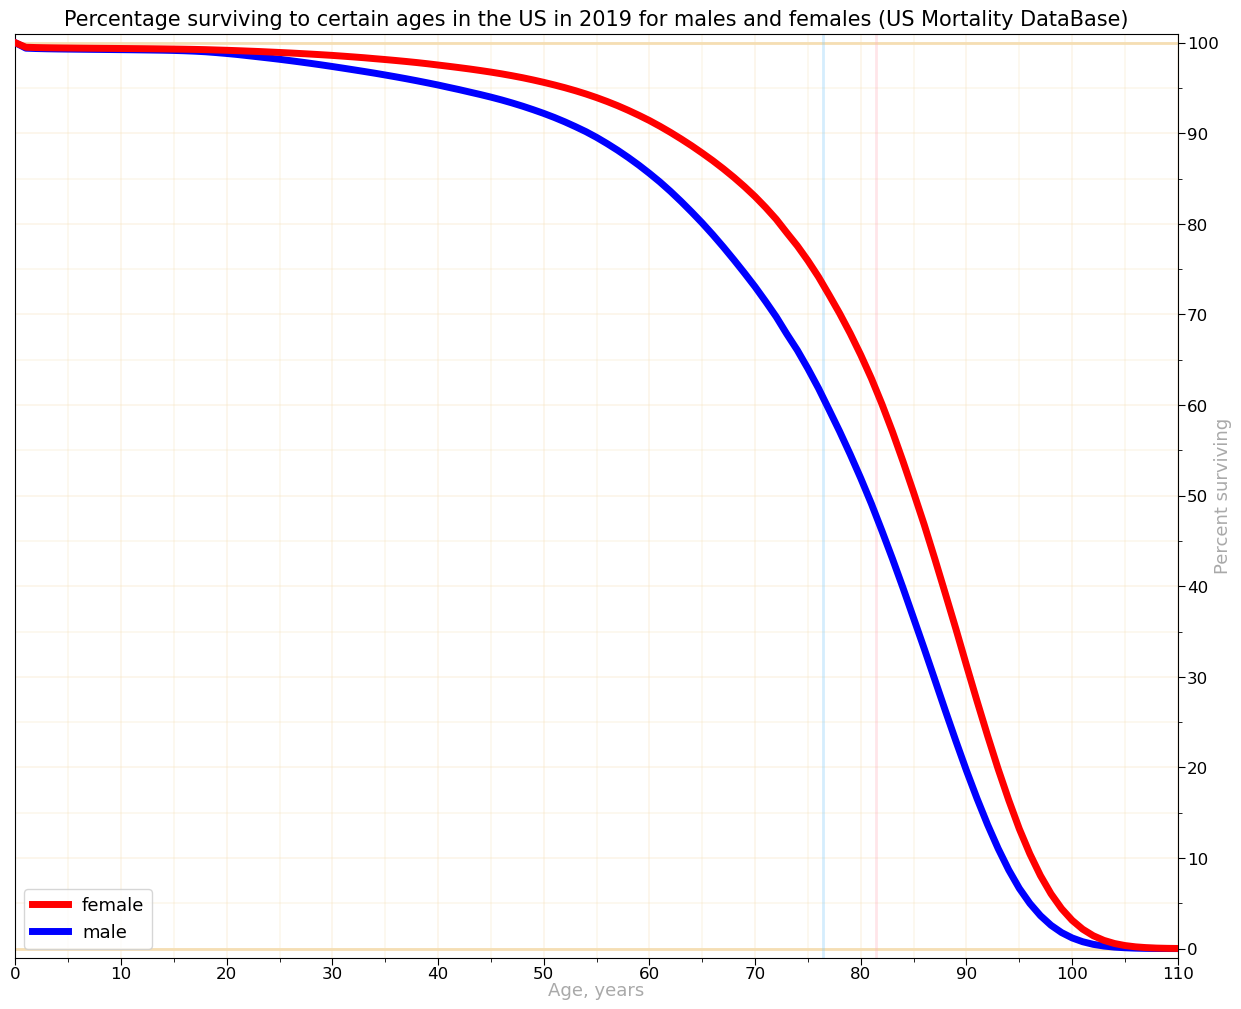

In [18]:
def create_chart(
        df, lang=LANG, dd_display='', ncol=2,
        title_en='Title of the chart', title_ru='Заголовок графика',
        le_male=None, le_female=None,
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (16, 12.5) if lang=='ru' else (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()  # show ticks only at the left side
    ax.yaxis.set_label_position("right")  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=3)  # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=3)  # Minor ticks are shorter
    plt.xticks(fontsize=12)  # font size for tick labels
    plt.yticks(fontsize=12)
    
    x_min = y_min = 0
    x_max = 110
    y_max = 100
    plt.xlim(0, 110)
    plt.ylim(-1, 101)

    # for version with ratio
    # labels_y = range(y_min, y_max+1, 10)
    # y_labels_names = ((f"{v/100:.1f}" if v % 100 != 0  else v//100) for v in labels_y)
    # plt.yticks(labels_y, labels=y_labels_names)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.3)

    plt.axhline(y=100, color='wheat', linewidth=2)
    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else title_en, fontsize=15)
    plt.xlabel('Возраст, годы' if lang=='ru' else 'Age, years', fontsize=13, color='darkgray', labelpad=-0.5)
    plt.ylabel('Процент выживших' if lang=='ru' else 'Percent surviving', fontsize=13, color='darkgray', labelpad=-3.5)
    # plt.ylabel('Доля выживших' if lang=='ru' else 'Survival Rate', fontsize=13, color='darkgray')  # , labelpad=-2

    if le_male:
        plt.axvline(x=le_male, color='lightskyblue', linewidth=2, alpha=0.35)
    if le_female:
        plt.axvline(x=le_female, color='lightpink', linewidth=2, alpha=0.35)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='lower left', fontsize=13, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print('Data has written to file')
    else:
        plt.show()


dd_display = {
    'females'       : DisplayedGroup(en_name='female',      ru_name='женщины',         color='red',  style='-',  width=5, alpha=1),
    # 'all_t'       : DisplayedGroup(en_name='Population Overall', ru_name='население в целом',       color='lightgrey',  style='-',  width=6, alpha=1),
    'males'       : DisplayedGroup(en_name='male',    ru_name='мужчины',         color='blue',  style='-', width=5, alpha=1),
}

create_chart(df.T.loc[['females', 'males']] / 1000,
             dd_display=dd_display, ncol=1, lang=LANG,
             title_en=f'Percentage surviving to certain ages in the US in {YEAR} for males and females (US Mortality DataBase)',  # , overall statistics for males and females
             title_ru=f'Процент выживших к определённому возрасту в США в {YEAR} для мужчин и женщин (US Mortality DataBase)',
             le_male=le_m_country, le_female=le_f_country,
             file_name='Percentage Surviving to Certain Ages in the US by USMDB')

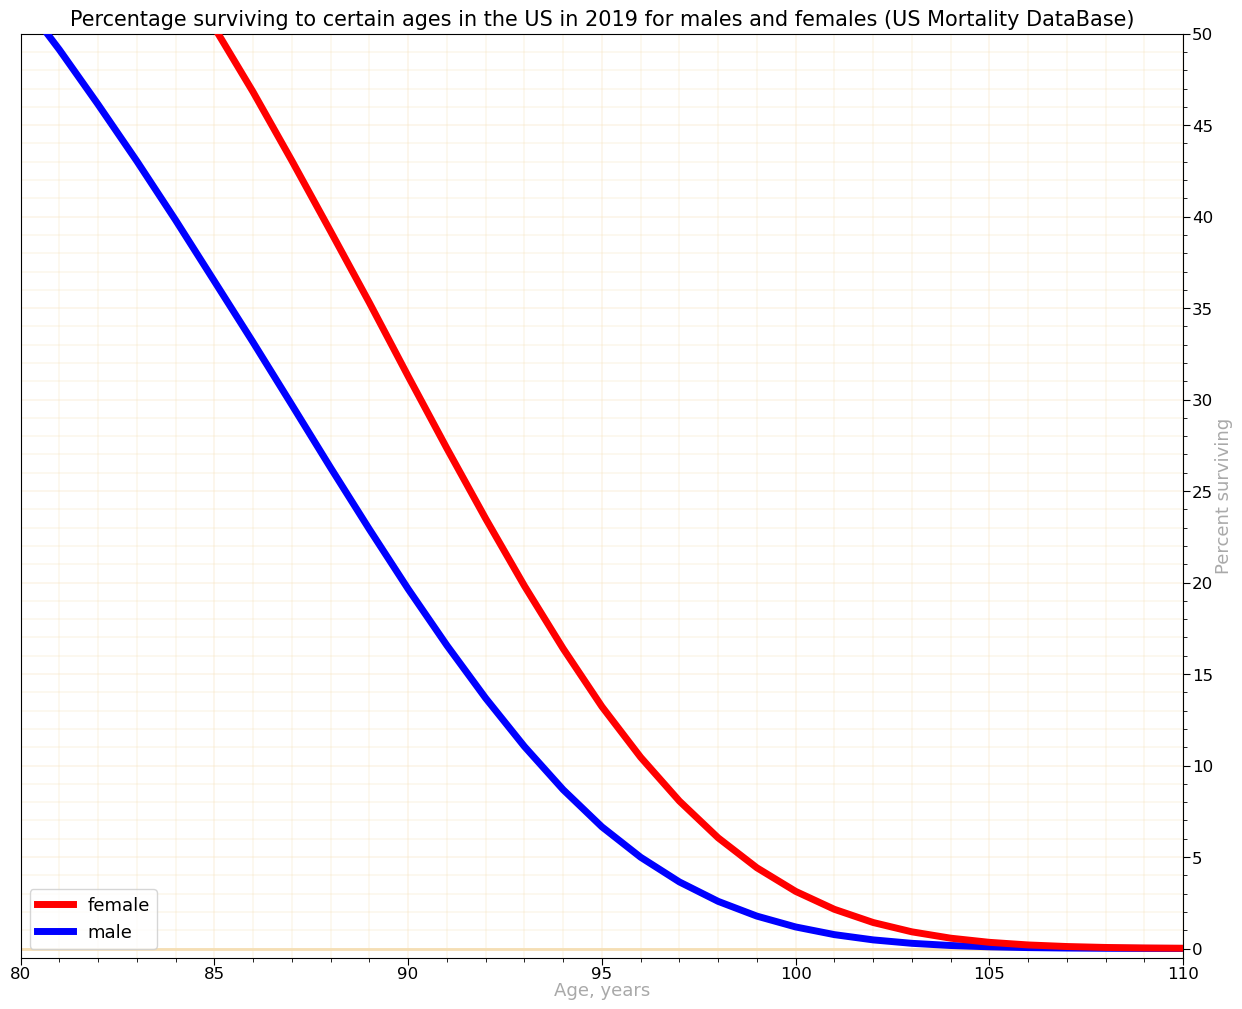

In [19]:
def create_chart_zoomed(
        df, lang=LANG, dd_display='', ncol=2,
        title_en='Title of the chart', title_ru='Заголовок графика',
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (16, 12.5) if lang=='ru' else (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()  # show ticks only at the left side
    ax.yaxis.set_label_position("right")  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(5))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(1))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=3)  # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=3)  # Minor ticks are shorter
    plt.xticks(fontsize=12)  # font size for tick labels
    plt.yticks(fontsize=12)
    
    x_min = y_min = 0
    x_max = 110
    y_max = 100
    plt.xlim(80, 110)
    plt.ylim(-0.5, 50)

    # for version with ratio
    # labels_y = range(y_min, y_max+1, 10)
    # y_labels_names = ((f"{v/100:.1f}" if v % 100 != 0  else v//100) for v in labels_y)
    # plt.yticks(labels_y, labels=y_labels_names)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.3)

    # plt.axhline(y=100, color='wheat', linewidth=2)
    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else title_en, fontsize=15)
    plt.xlabel('Возраст, годы' if lang=='ru' else 'Age, years', fontsize=13, color='darkgray', labelpad=-0.5)
    plt.ylabel('Процент выживших' if lang=='ru' else 'Percent surviving', fontsize=13, color='darkgray', labelpad=1)
    # plt.ylabel('Доля выживших' if lang=='ru' else 'Survival Rate', fontsize=13, color='darkgray')  # , labelpad=-2
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='lower left', fontsize=13, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print('Data has written to file')
    else:
        plt.show()


dd_display = {
    'females'       : DisplayedGroup(en_name='female',      ru_name='женщины',         color='red',  style='-',  width=5, alpha=1),
    # 'all_t'       : DisplayedGroup(en_name='Population Overall', ru_name='население в целом',       color='lightgrey',  style='-',  width=6, alpha=1),
    'males'       : DisplayedGroup(en_name='male',    ru_name='мужчины',         color='blue',  style='-', width=5, alpha=1),
}

create_chart_zoomed(df.T.loc[['females', 'males']] / 1000,
             dd_display=dd_display, ncol=1, lang=LANG,
             title_en=f'Percentage surviving to certain ages in the US in {YEAR} for males and females (US Mortality DataBase)',  # , overall statistics for males and females
             title_ru=f'Процент выживших к определённому возрасту в США в {YEAR} для мужчин и женщин (US Mortality DataBase)',
             file_name='Percentage Surviving to Certain Ages in the US by USMDB -zoomed')

<br>

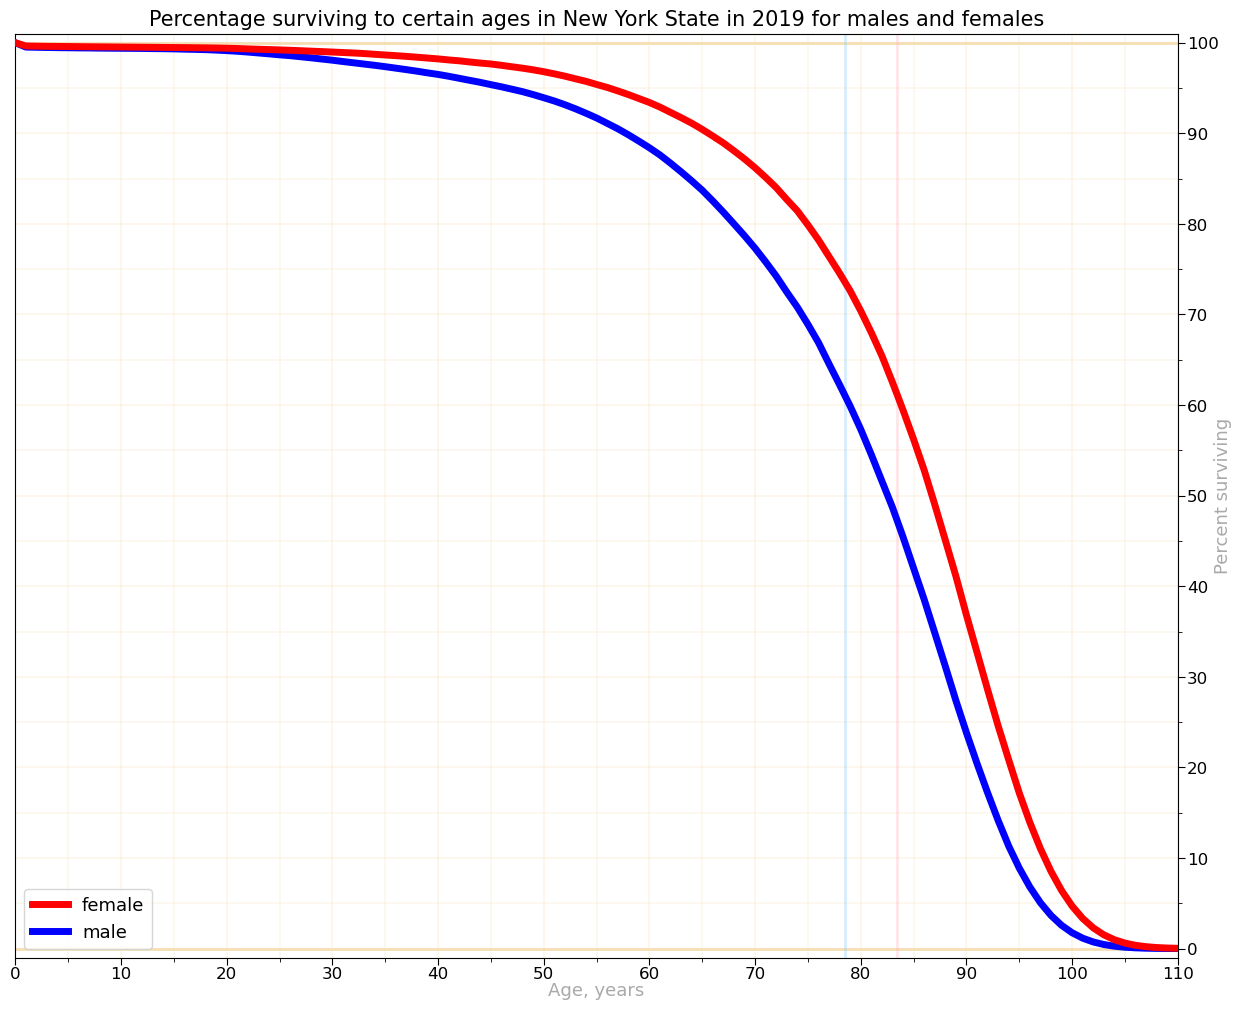

In [21]:
# chart for New York State

if ST1 == 'NY':
    create_chart(df.T.loc[['females_st1', 'males_st1']] \
                   .rename(index={'females_st1': 'females', 'males_st1': 'males'}) / 1000,
                 dd_display=dd_display, ncol=1, lang=LANG,
                 title_en=f'Percentage surviving to certain ages in New York State in {YEAR} for males and females',
                 title_ru=f'Процент выживших к определённому возрасту в штате Нью-Йорк в {YEAR} для мужчин и женщин',
                 le_male=le_m_st1, le_female=le_f_st1,
                 file_name='Percentage Surviving to Certain Ages in New York State')

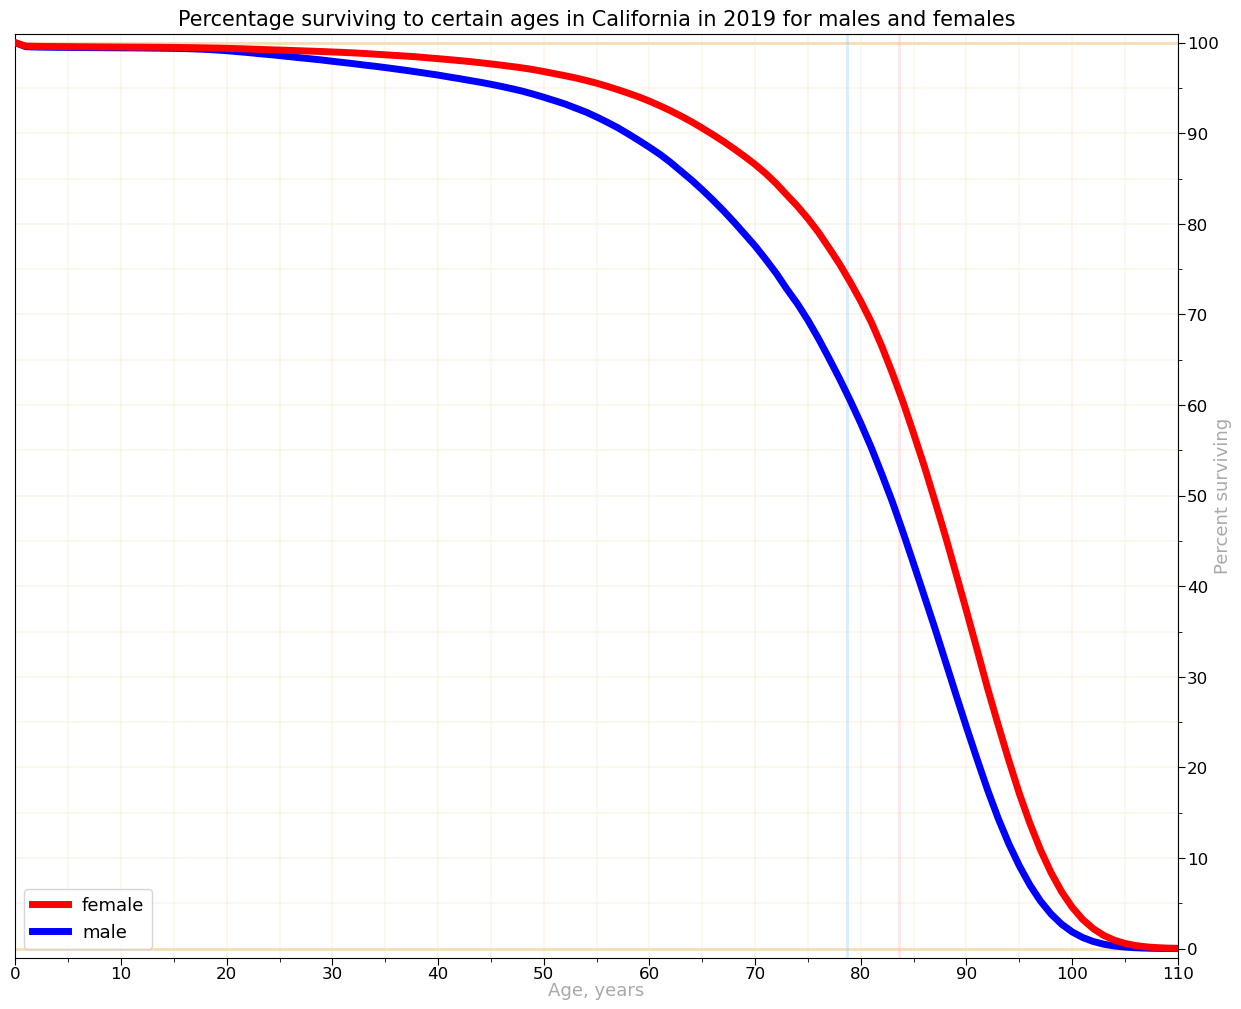

In [22]:
# chart for California

if ST2 == 'CA':
    create_chart(df.T.loc[['females_st2', 'males_st2']] \
                   .rename(index={'females_st2': 'females', 'males_st2': 'males'}) / 1000,
                 dd_display=dd_display, ncol=1, lang=LANG,
                 title_en=f'Percentage surviving to certain ages in California in {YEAR} for males and females',
                 title_ru=f'Процент выживших к определённому возрасту в Калифорнии в {YEAR} для мужчин и женщин',
                 le_male=le_m_st2, le_female=le_f_st2,
                 file_name='Percentage Surviving to Certain Ages in California')

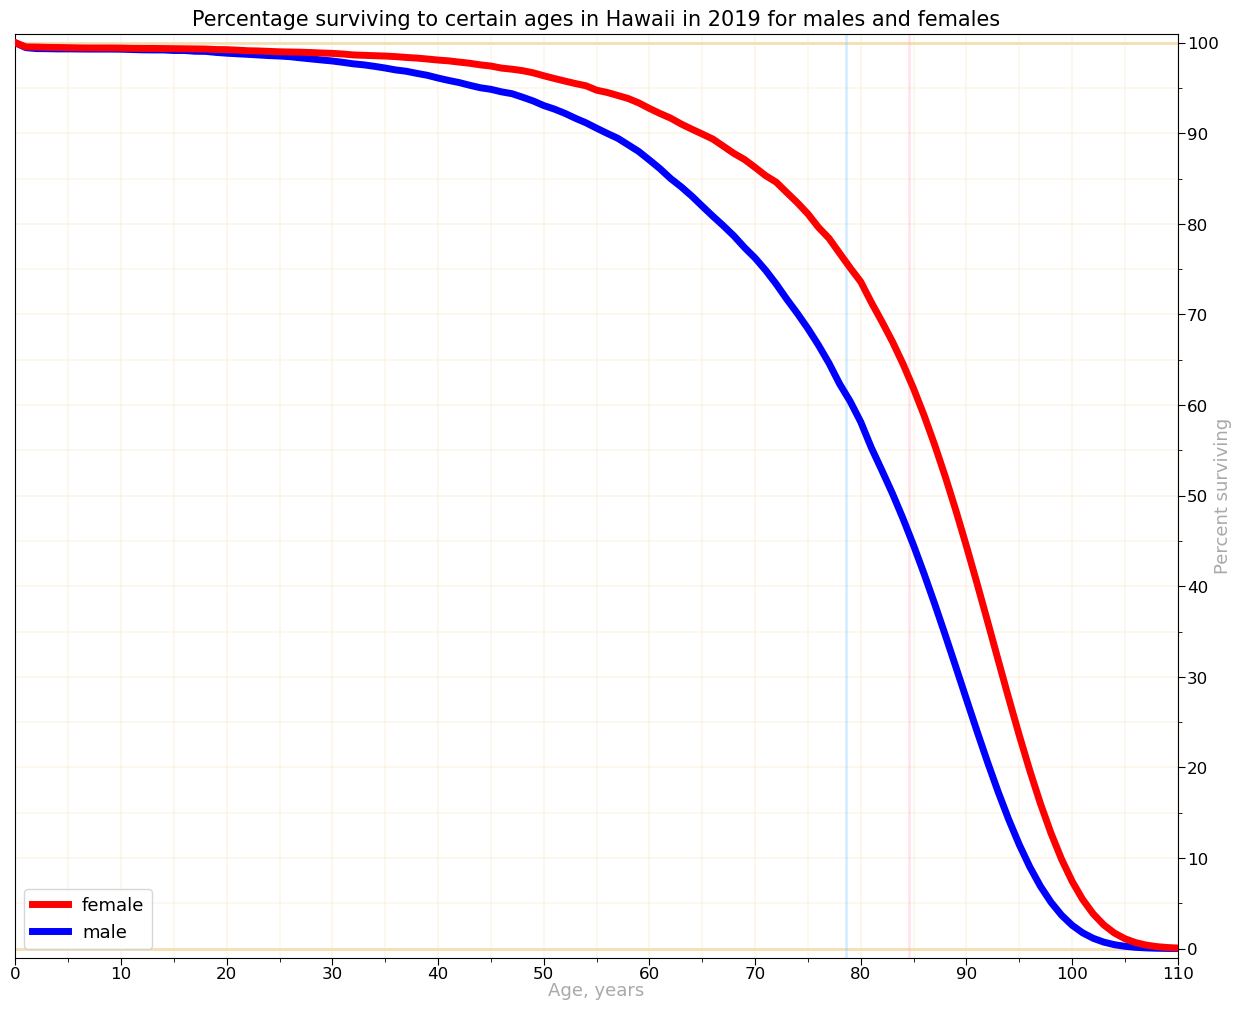

In [23]:
# chart for Hawaii

if ST3 == 'HI':
    create_chart(df.T.loc[['females_st3', 'males_st3']] \
                   .rename(index={'females_st3': 'females', 'males_st3': 'males'}) / 1000,
                 dd_display=dd_display, ncol=1, lang=LANG,
                 title_en=f'Percentage surviving to certain ages in Hawaii in {YEAR} for males and females',
                 title_ru=f'Процент выживших к определённому возрасту на Гавайях в {YEAR} для мужчин и женщин',
                 le_male=le_m_st3, le_female=le_f_st3,
                 file_name='Percentage Surviving to Certain Ages in Hawaii')